In [1]:
import sys
sys.path.append('../')
from utils_models import *


ImportError: cannot import name 'timecallable' from 'dynamiqs' (unknown location)

In [2]:
amp_with_2pi = 0.011026707187734986
flux = 0.40367803977430805
pulse_length = 308.37376398206834-6

t_rise = 30
t_tot = t_rise + pulse_length
t_tot

332.37376398206834

In [3]:
tlist = np.linspace(0,t_tot,int(t_tot))

In [4]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
    EJmax=50,
    EC=0.5,
    d=0.01,
    flux=flux,
    ng=0.0,
    ncut=30,
    truncated_dim = 4
    )
system = FluxoniumTunableTransmonSystem(
    fluxonium  = fluxonium,
    tune_tmon = tune_tmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    )


In [5]:

w_d = system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]
w_d

7.181825067489516

In [6]:
e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))
e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(7,0)]))))
results = system.run_dq_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.tune_tmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': t_rise,
                    't_square': pulse_length - t_rise
                  },
                # pulse_shape_func=gaussian_pulse,
                # pulse_shape_args={
                #     'w_d': w_d,
                #     'amp': amp_with_2pi/(2*np.pi),
                #     't_duration': t_tot, 
                #     'sigma':sigma
                #     },
                )],
        c_ops = None,
        e_ops = e_ops
    )


AttributeError: module 'dynamiqs' has no attribute 'time_array'

(300.0, 330.0)

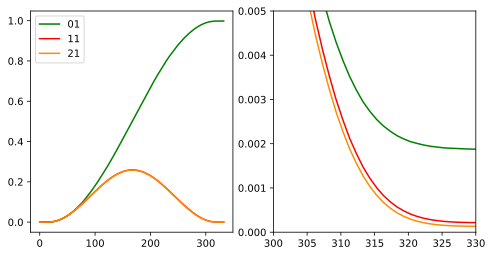

In [ ]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for ql in range(3):
    for tl in [1]:
        i = ql*4+tl
        axes[0].plot(tlist,results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])
        axes[1].plot(tlist,results[ql].expect[i] if not (ql == 0 and tl ==1)  else 1- results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])

axes[0].legend()
axes[1].set_ylim(0,0.005)
axes[1].set_xlim(300,330)

(-0.001, 0.02)

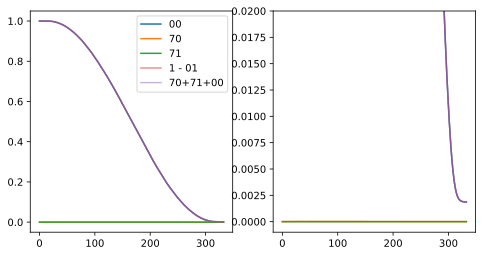

In [ ]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for ql,tl in [(0,0),(7,0),(7,1)]:
    i = ql*4+tl
    axes[0].plot(tlist,results[0].expect[i],label = f"{ql}{tl}")
axes[0].plot(tlist,1 - results[0].expect[1],label = f"1 - 01",alpha = 0.5)
axes[0].plot(tlist,results[0].expect[4*7+0] + results[0].expect[4*7+1] + results[0].expect[0] ,label = f"70+71+00",alpha = 0.5)


for ql,tl in [(0,0),(7,0),(7,1)]:
    i = ql*4+tl
    axes[1].plot(tlist,results[0].expect[i],label = f"{ql}{tl}")
axes[1].plot(tlist,1 - results[0].expect[1],label = f"1 - 01",alpha = 0.5)
axes[1].plot(tlist,results[0].expect[4*7+0] + results[0].expect[4*7+1] + results[0].expect[0] ,label = f"70+71+00",alpha = 0.5)



axes[0].legend()
axes[1].set_ylim(-0.001,0.02)

In [ ]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()
overlap_matrix = scqubits.utils.spectrum_utils.convert_evecs_to_ndarray(evecs)


print(f"\t\tqubit 0\t\t\tqubit 1 \t\t qubit 2")

print(f"osc lvl\t\tdressed-overlap^2\tdressed-overlap^2\tdressed-overlap^2")
for i in range(10):
    product_index_q0 = 0 * system.tune_tmon.truncated_dim + i
    product_index_q1 = 1 * system.tune_tmon.truncated_dim + i
    product_index_q2 = 2 * system.tune_tmon.truncated_dim + i

    overlaps_with_product_state_q0 = np.abs(overlap_matrix[:, product_index_q0])
    sorted_indices_q0 = np.argsort(overlaps_with_product_state_q0)[::-1]
    sorted_overlaps_q0 = overlaps_with_product_state_q0[sorted_indices_q0]

    overlaps_with_product_state_q1 = np.abs(overlap_matrix[:, product_index_q1])
    sorted_indices_q1 = np.argsort(overlaps_with_product_state_q1)[::-1]
    sorted_overlaps_q1 = overlaps_with_product_state_q1[sorted_indices_q1]
    
    overlaps_with_product_state_q2 = np.abs(overlap_matrix[:, product_index_q2])
    sorted_indices_q2 = np.argsort(overlaps_with_product_state_q2)[::-1]
    sorted_overlaps_q2 = overlaps_with_product_state_q2[sorted_indices_q2]

    print(f"tl-{i}:\t\t{list(sorted_indices_q0)[0]}-{list(sorted_overlaps_q0)[0]**2:.3f} \t\t{list(sorted_indices_q1)[0]}-{list(sorted_overlaps_q1)[0]**2:.3f} \t\t{list(sorted_indices_q2)[0]}-{list(sorted_overlaps_q2)[0]**2:.3f}")

		qubit 0			qubit 1 		 qubit 2
osc lvl		dressed-overlap^2	dressed-overlap^2	dressed-overlap^2
tl-0:		0-1.000 		1-1.000 		2-1.000
tl-1:		7-0.951 		12-0.995 		13-0.998
tl-2:		24-0.997 		29-0.998 		30-0.995
tl-3:		41-0.996 		48-0.987 		49-0.995
tl-4:		1-1.000 		2-1.000 		3-0.999
tl-5:		12-0.995 		13-0.998 		15-0.995
tl-6:		29-0.998 		30-0.995 		34-0.967
tl-7:		48-0.987 		49-0.995 		50-0.990
tl-8:		2-1.000 		3-0.999 		4-0.999
tl-9:		13-0.998 		15-0.995 		18-0.995
